# 04 — 3-class sentiment models on spam-cleaned data

Builds and tunes four sentiment classifiers, all restricted to the allowed lectures:

1. **Word-list classifier** with margin $\delta$ (W02_L04)
2. **Multinomial Naive Bayes** on TF-IDF (W03_L05 + W05_L09)
3. **Logistic Regression** on TF-IDF (W03_L05 + W05_L09)
4. **Logistic Regression** on averaged Word2Vec embeddings (W05_L09)

All models are trained on the **spam-cleaned** training set (cosine filter from `03`; see `data/CARRY_FORWARD_FILTER.txt`). Predictions are made 3-class by routing val docs flagged by the same filter to the dummy label $-1$. Ground-truth $-1$ for evaluation is the regex proxy from `01`/`03` — this is the same proxy used to tune the filter, so the $-1$ vs $-1$ entries of the confusion matrix should be read as a *consistency* check, not a clean test (caveat reiterated at evaluation time). The clean test set is not touched.

An ablation re-trains Model 3 on the *uncleaned* training set so the contamination cost is visible in the report.

In [1]:
%pip install -q gensim


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, re, json, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

from gensim.models import Word2Vec

sys.path.insert(0, str(Path.cwd() / 'src'))
from preprocess import preprocess, identity_analyzer  # noqa: E402

plt.rcParams['font.size'] = 12
RNG = 42
LABELS_3 = [-1, 0, 1]

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


## 1. Load data, preprocess, apply carry-forward spam filter

In [3]:
DATA_DIR  = Path('..') / 'data'
OUT_DATA  = Path('data');    OUT_DATA.mkdir(exist_ok=True)
FIG_DIR   = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('models');  MODEL_DIR.mkdir(exist_ok=True)
RES_DIR   = Path('results'); RES_DIR.mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'sentiment_analysis_training_data.csv')
val_df   = pd.read_csv(DATA_DIR / 'sentiment_analysis_validation_data.csv')
print('train:', train_df.shape, ' val:', val_df.shape)

train_tokens = [preprocess(t) for t in train_df['text'].tolist()]
val_tokens   = [preprocess(t) for t in val_df['text'].tolist()]
print('preprocessed:', len(train_tokens), len(val_tokens))

train: (11503, 2)  val: (1397, 2)


preprocessed: 11503 1397


In [4]:
carry = (OUT_DATA / 'CARRY_FORWARD_FILTER.txt').read_text().strip()
print('carry-forward filter file:', carry)
masks = np.load(OUT_DATA / carry)
is_spam_train = masks['is_spam_train']
is_spam_val   = masks['is_spam_val']
print(f'train flagged: {is_spam_train.mean():.3f}  val flagged: {is_spam_val.mean():.3f}')

# Proxy regex from 01 — used only for 3-class GROUND TRUTH on val.
SPAM_RE = re.compile(r'(?im)^\s*subject\s*:|\benron\b|\bunsubscribe\b')
is_spam_proxy_val = val_df['text'].apply(lambda t: bool(SPAM_RE.search(t))).values
print(f'val proxy rate: {is_spam_proxy_val.mean():.3f}')

carry-forward filter file: spam_mask_cosine.npz
train flagged: 0.225  val flagged: 0.210
val proxy rate: 0.237


In [5]:
# Cleaned training set: drop spam-flagged docs
keep_train = ~is_spam_train
train_tokens_clean = [toks for toks, k in zip(train_tokens, keep_train) if k]
y_train_clean = train_df.loc[keep_train, 'label'].astype(int).values
print(f'cleaned train: {len(train_tokens_clean)} docs  '
      f'(pos={int((y_train_clean==1).sum())}, neg={int((y_train_clean==0).sum())})')

# 3-class val ground truth: proxy spam → -1, otherwise binary label
y_val_3 = val_df['label'].astype(int).values.copy()
y_val_3[is_spam_proxy_val] = -1
print('val 3-class counts:', dict(zip(*np.unique(y_val_3, return_counts=True))))

cleaned train: 8919 docs  (pos=4464, neg=4455)
val 3-class counts: {np.int64(-1): np.int64(331), np.int64(0): np.int64(533), np.int64(1): np.int64(533)}


### 1.1 3-class evaluation harness

For every model we:
1. Predict 0/1 on val with the trained model (any features).
2. Override the prediction to $-1$ wherever `is_spam_val` (the cosine carry-forward filter from `03`) flags the doc.
3. Score the resulting 3-class prediction against `y_val_3` (which uses the proxy regex for $-1$ ground truth).

**Caveat (in report and again here):** the filter and the ground-truth $-1$ are both derived from spam signals — cosine vs. regex respectively. They are not independent. So the $-1/-1$ diagonal cell mainly measures how well the cosine filter agrees with the regex proxy; it is *not* a clean test of detecting unseen spam. The honest verdict on whether spam handling helps is the *binary* slice (rows/cols 0/1) compared with the contamination ablation at §6.

In [6]:
def predict_3class(binary_preds, spam_mask):
    out = np.array(binary_preds, dtype=int)
    out[spam_mask] = -1
    return out

def score_3class(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, labels=LABELS_3,
                                     average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, labels=LABELS_3,
                                  average='macro', zero_division=0),
        'f1':        f1_score(y_true, y_pred, labels=LABELS_3,
                              average='macro', zero_division=0),
    }

def plot_confusion(y_true, y_pred, title, save_to):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_3)
    fig, ax = plt.subplots(figsize=(5, 4.2))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_xticklabels([f'pred {l}' for l in LABELS_3])
    ax.set_yticks(range(3)); ax.set_yticklabels([f'true {l}' for l in LABELS_3])
    thresh = cm.max() / 2.0 if cm.max() else 1
    for i in range(3):
        for j in range(3):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=11)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_to, dpi=150)
    plt.show()
    return cm

TIMINGS = []  # rows for results/timings.csv
RESULTS = []  # rows for results/model_comparison.csv

## 2. Model 1 — Word-list classifier with margin $\delta$ (W02_L04)

Following the W02_L04 decision rule (Eq. 1 of §3.2 in the report):

$$\hat y(d) = \begin{cases}1 & \text{if } c_+(d) > c_-(d) + \delta \\ 0 & \text{if } c_-(d) > c_+(d) + \delta \\ -1 & \text{otherwise}\end{cases}$$

where $c_\pm(d) = |\{t \in d : t \in L_\pm\}|$ with multiplicities. The lists $L_+ / L_-$ are built by the **greatest-frequency-difference** method on the **cleaned** training tokens (so they differ from the lists used in `03` for spam detection). We sweep $K \in \{50, 100, 200, 500\}$ and $\delta \in \{0, 1, 2, 3\}$ jointly on 3-class val accuracy. The spam filter is still applied to val first.

In [7]:
pos_counter = Counter(); neg_counter = Counter()
for toks, y in zip(train_tokens_clean, y_train_clean):
    (pos_counter if y == 1 else neg_counter).update(toks)
n_pos_tok = sum(pos_counter.values()); n_neg_tok = sum(neg_counter.values())
vocab_full = set(pos_counter) | set(neg_counter)
rows = []
for w in vocab_full:
    fp = pos_counter[w] / max(n_pos_tok, 1)
    fn = neg_counter[w] / max(n_neg_tok, 1)
    rows.append((w, fp, fn, fp - fn))
freq_df = pd.DataFrame(rows, columns=['token', 'fp', 'fn', 'diff'])
freq_df['absdiff'] = freq_df['diff'].abs()
freq_df = freq_df.sort_values('absdiff', ascending=False).reset_index(drop=True)
print('top 10 by |fp − fn| on cleaned tokens:')
print(freq_df.head(10).to_string(index=False))

top 10 by |fp − fn| on cleaned tokens:
token       fp       fn      diff  absdiff
    ' 0.033051 0.004685  0.028366 0.028366
  com 0.011296 0.001593  0.009702 0.009702
  ect 0.004985 0.000158  0.004827 0.004827
movie 0.006109 0.010064 -0.003955 0.003955
  net 0.003602 0.000174  0.003428 0.003428
  bad 0.000403 0.002824 -0.002420 0.002420
    ? 0.002478 0.004890 -0.002412 0.002412
 like 0.003818 0.006136 -0.002318 0.002318
  hou 0.002248 0.000063  0.002184 0.002184
  aol 0.002046 0.000016  0.002030 0.002030


In [8]:
def wl_predict(token_lists, Lp, Ln, delta):
    preds = np.empty(len(token_lists), dtype=int)
    for i, toks in enumerate(token_lists):
        cp = sum(1 for t in toks if t in Lp)
        cn = sum(1 for t in toks if t in Ln)
        if cp > cn + delta:
            preds[i] = 1
        elif cn > cp + delta:
            preds[i] = 0
        else:
            preds[i] = -1
    return preds

K_grid = [50, 100, 200, 500]
delta_grid = [0, 1, 2, 3]
best_wl = None  # (acc, K, delta, Lp, Ln, preds)
rows = []
for K in K_grid:
    Lp = set(freq_df[freq_df['diff'] > 0].head(K)['token'])
    Ln = set(freq_df[freq_df['diff'] < 0].head(K)['token'])
    for d in delta_grid:
        bin_preds = wl_predict(val_tokens, Lp, Ln, d)  # already 3-class (uses -1 internally)
        # Force spam-filter override on the -1 channel:
        preds_3 = bin_preds.copy()
        preds_3[is_spam_val] = -1
        acc = accuracy_score(y_val_3, preds_3)
        rows.append((K, d, len(Lp | Ln), acc))
        if best_wl is None or acc > best_wl[0]:
            best_wl = (acc, K, d, Lp, Ln, preds_3)
wl_grid_df = pd.DataFrame(rows, columns=['K', 'delta', '|L|', 'val_acc_3'])
print(wl_grid_df.to_string(index=False))
print(f'\nbest: K={best_wl[1]}, delta={best_wl[2]}, val 3-class acc={best_wl[0]:.4f}')

  K  delta  |L|  val_acc_3
 50      0  100   0.540444
 50      1  100   0.370079
 50      2  100   0.275591
 50      3  100   0.246242
100      0  200   0.593414
100      1  200   0.426628
100      2  200   0.310666
100      3  200   0.260558
200      0  400   0.632069
200      1  400   0.479599
200      2  400   0.358626
200      3  400   0.293486
500      0 1000   0.670723
500      1 1000   0.544023
500      2 1000   0.443092
500      3 1000   0.342162

best: K=500, delta=0, val 3-class acc=0.6707


{'accuracy': 0.6707, 'precision': 0.681, 'recall': 0.6951, 'f1': 0.6747}


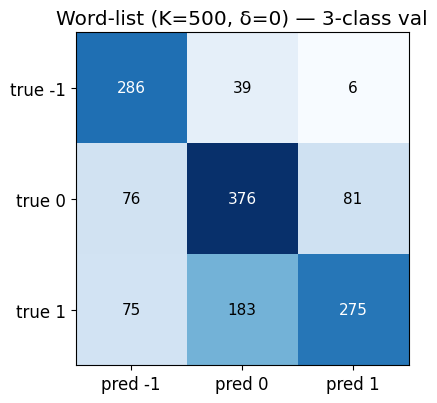

In [9]:
_, K_wl, d_wl, Lp_wl, Ln_wl, preds_wl = best_wl
t0 = time.perf_counter()
_ = wl_predict(train_tokens_clean, Lp_wl, Ln_wl, d_wl)  # 'fit' is list building (above); time the training-set scan as a proxy
t_wl = time.perf_counter() - t0

m_wl = score_3class(y_val_3, preds_wl)
print({k: round(v, 4) for k, v in m_wl.items()})
_ = plot_confusion(y_val_3, preds_wl,
                   f'Word-list (K={K_wl}, δ={d_wl}) — 3-class val',
                   FIG_DIR / 'confusion_wordlist.png')

joblib.dump({'K': K_wl, 'delta': d_wl, 'L_pos': Lp_wl, 'L_neg': Ln_wl, 'metrics': m_wl},
            MODEL_DIR / 'wordlist.joblib')

TIMINGS.append(dict(model='wordlist', train_seconds=t_wl, n_train=len(train_tokens_clean),
                    ngram_range='(1,1)',
                    best_hyperparams=json.dumps({'K': K_wl, 'delta': d_wl})))
RESULTS.append(dict(model='wordlist',
                    hyperparams=json.dumps({'K': K_wl, 'delta': d_wl}),
                    ngram_range='(1,1)',
                    val_acc=m_wl['accuracy'], val_f1=m_wl['f1'],
                    train_seconds=t_wl))

## 3. Model 2 — Multinomial Naive Bayes on TF-IDF (W03_L05)

**Assumption.** Multinomial NB assumes features are *conditionally independent given the class* — hence the "naive" label in W03_L05. With BoW/TF-IDF features this means co-occurrence between words within a class is treated as independent, which is plainly wrong linguistically but works surprisingly well on text.

**MLE (with Laplace smoothing $\alpha$):**
$$P(c) = \frac{N_c}{N},\qquad P(f\mid c) = \frac{\mathrm{count}(f, c) + \alpha}{\sum_{f'}\mathrm{count}(f', c) + \alpha\,|V|}$$

Sweep $\alpha \in \{0.01, 0.1, 0.5, 1.0, 2.0\}$ and `ngram_range` $\in \{(1,1), (1,2)\}$ on the **cleaned** training set, scored as 3-class on val.

In [10]:
alpha_grid = [0.01, 0.1, 0.5, 1.0, 2.0]
ngram_grid = [(1, 1), (1, 2)]

best_mnb = None  # (acc, alpha, ngram, vec, clf, preds_3)
rows = []
for ngram in ngram_grid:
    vec = TfidfVectorizer(analyzer=identity_analyzer,
                          tokenizer=None, preprocessor=None,
                          lowercase=False, min_df=2, ngram_range=ngram)
    Xtr = vec.fit_transform(train_tokens_clean)
    Xva = vec.transform(val_tokens)
    for a in alpha_grid:
        clf = MultinomialNB(alpha=a)
        clf.fit(Xtr, y_train_clean)
        bin_preds = clf.predict(Xva)
        preds_3 = predict_3class(bin_preds, is_spam_val)
        acc = accuracy_score(y_val_3, preds_3)
        rows.append((ngram, a, len(vec.vocabulary_), acc))
        if best_mnb is None or acc > best_mnb[0]:
            best_mnb = (acc, a, ngram, vec, clf, preds_3)
mnb_grid_df = pd.DataFrame(rows, columns=['ngram', 'alpha', '|V|', 'val_acc_3'])
print(mnb_grid_df.to_string(index=False))
print(f'\nbest: alpha={best_mnb[1]}, ngram={best_mnb[2]}, val 3-class acc={best_mnb[0]:.4f}')

 ngram  alpha  |V|  val_acc_3
(1, 1)   0.01 8990   0.764495
(1, 1)   0.10 8990   0.776664
(1, 1)   0.50 8990   0.789549
(1, 1)   1.00 8990   0.788117
(1, 1)   2.00 8990   0.785970
(1, 2)   0.01 8990   0.764495
(1, 2)   0.10 8990   0.776664
(1, 2)   0.50 8990   0.789549
(1, 2)   1.00 8990   0.788117
(1, 2)   2.00 8990   0.785970

best: alpha=0.5, ngram=(1, 1), val 3-class acc=0.7895


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


{'accuracy': 0.7895, 'precision': 0.8182, 'recall': 0.7986, 'f1': 0.8071}


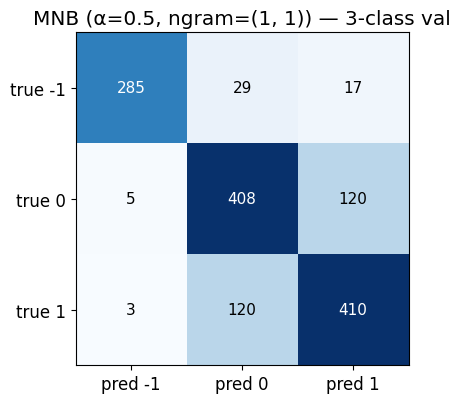

In [11]:
_, a_mnb, ng_mnb, vec_mnb, clf_mnb, preds_mnb = best_mnb
# Time the refit at the best config so the timing is comparable across models.
t0 = time.perf_counter()
vec_t = TfidfVectorizer(analyzer=identity_analyzer, tokenizer=None, preprocessor=None,
                        lowercase=False, min_df=2, ngram_range=ng_mnb)
Xtr = vec_t.fit_transform(train_tokens_clean)
clf_t = MultinomialNB(alpha=a_mnb).fit(Xtr, y_train_clean)
t_mnb = time.perf_counter() - t0

m_mnb = score_3class(y_val_3, preds_mnb)
print({k: round(v, 4) for k, v in m_mnb.items()})
_ = plot_confusion(y_val_3, preds_mnb,
                   f'MNB (α={a_mnb}, ngram={ng_mnb}) — 3-class val',
                   FIG_DIR / 'confusion_mnb.png')

joblib.dump({'vectoriser': vec_mnb, 'model': clf_mnb,
             'alpha': a_mnb, 'ngram_range': ng_mnb, 'metrics': m_mnb},
            MODEL_DIR / 'mnb.joblib')
TIMINGS.append(dict(model='mnb', train_seconds=t_mnb, n_train=len(train_tokens_clean),
                    ngram_range=str(ng_mnb),
                    best_hyperparams=json.dumps({'alpha': a_mnb})))
RESULTS.append(dict(model='mnb',
                    hyperparams=json.dumps({'alpha': a_mnb}),
                    ngram_range=str(ng_mnb),
                    val_acc=m_mnb['accuracy'], val_f1=m_mnb['f1'],
                    train_seconds=t_mnb))

## 4. Model 3 — Logistic Regression on TF-IDF (W03_L05)

The W03_L05 binary LR:
$$P(y=1\mid x) = \sigma(w^\top x) = \frac{1}{1 + e^{-w^\top x}}$$
trained by minimising the binary cross-entropy loss (Eq. 3 of the report). The sklearn default is L2-regularised; the strength is parameterised as $C = 1/\lambda$, swept across $\{0.01, 0.1, 1.0, 10.0\}$ together with `ngram_range` $\in \{(1,1), (1,2)\}$. Training on the cleaned set, 3-class scoring on val with the spam filter.

In [12]:
C_grid = [0.01, 0.1, 1.0, 10.0]
ngram_grid = [(1, 1), (1, 2)]

best_lr = None
rows = []
for ngram in ngram_grid:
    vec = TfidfVectorizer(analyzer=identity_analyzer, tokenizer=None, preprocessor=None,
                          lowercase=False, min_df=2, ngram_range=ngram)
    Xtr = vec.fit_transform(train_tokens_clean)
    Xva = vec.transform(val_tokens)
    for C in C_grid:
        clf = LogisticRegression(max_iter=2000, random_state=RNG, C=C)
        clf.fit(Xtr, y_train_clean)
        bin_preds = clf.predict(Xva)
        preds_3 = predict_3class(bin_preds, is_spam_val)
        acc = accuracy_score(y_val_3, preds_3)
        rows.append((ngram, C, len(vec.vocabulary_), acc))
        if best_lr is None or acc > best_lr[0]:
            best_lr = (acc, C, ngram, vec, clf, preds_3)
lr_grid_df = pd.DataFrame(rows, columns=['ngram', 'C', '|V|', 'val_acc_3'])
print(lr_grid_df.to_string(index=False))
print(f'\nbest: C={best_lr[1]}, ngram={best_lr[2]}, val 3-class acc={best_lr[0]:.4f}')

 ngram     C  |V|  val_acc_3
(1, 1)  0.01 8990   0.745884
(1, 1)  0.10 8990   0.760200
(1, 1)  1.00 8990   0.777380
(1, 1) 10.00 8990   0.769506
(1, 2)  0.01 8990   0.745884
(1, 2)  0.10 8990   0.760200
(1, 2)  1.00 8990   0.777380
(1, 2) 10.00 8990   0.769506

best: C=1.0, ngram=(1, 1), val 3-class acc=0.7774


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


{'accuracy': 0.7774, 'precision': 0.808, 'recall': 0.7879, 'f1': 0.7967}


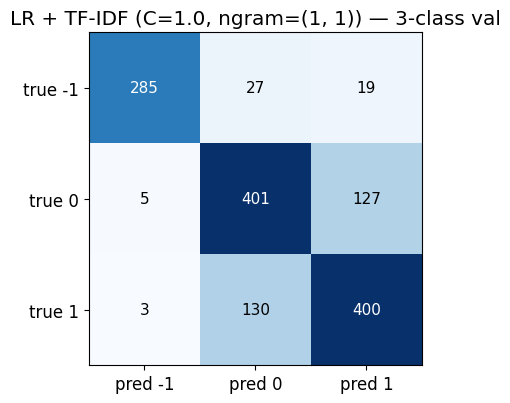

In [13]:
_, C_lr, ng_lr, vec_lr, clf_lr, preds_lr = best_lr
t0 = time.perf_counter()
vec_t = TfidfVectorizer(analyzer=identity_analyzer, tokenizer=None, preprocessor=None,
                        lowercase=False, min_df=2, ngram_range=ng_lr)
Xtr = vec_t.fit_transform(train_tokens_clean)
clf_t = LogisticRegression(max_iter=2000, random_state=RNG, C=C_lr).fit(Xtr, y_train_clean)
t_lr = time.perf_counter() - t0

m_lr = score_3class(y_val_3, preds_lr)
print({k: round(v, 4) for k, v in m_lr.items()})
_ = plot_confusion(y_val_3, preds_lr,
                   f'LR + TF-IDF (C={C_lr}, ngram={ng_lr}) — 3-class val',
                   FIG_DIR / 'confusion_lr_tfidf.png')

joblib.dump({'vectoriser': vec_lr, 'model': clf_lr,
             'C': C_lr, 'ngram_range': ng_lr, 'metrics': m_lr},
            MODEL_DIR / 'lr_tfidf.joblib')
TIMINGS.append(dict(model='lr_tfidf', train_seconds=t_lr, n_train=len(train_tokens_clean),
                    ngram_range=str(ng_lr),
                    best_hyperparams=json.dumps({'C': C_lr})))
RESULTS.append(dict(model='lr_tfidf',
                    hyperparams=json.dumps({'C': C_lr}),
                    ngram_range=str(ng_lr),
                    val_acc=m_lr['accuracy'], val_f1=m_lr['f1'],
                    train_seconds=t_lr))

## 5. Model 4 — Logistic Regression on averaged Word2Vec (W05_L09)

W05_L09 motivates dense embeddings on the grounds that they let semantically similar tokens share statistical strength — e.g. *fantastic* and *brilliant* sit near each other in vector space instead of being two orthogonal sparse dimensions. The lecture's argument is that this *can* outperform sparse BoW/TF-IDF when training data is limited; whether it actually does here on ~8.5k cleaned docs is an empirical question for the comparison table.

We train skip-gram Word2Vec on the cleaned tokens (no embedding fine-tuning), average the in-vocab token vectors per document (zero vector if none), standardise, and feed to LR. Sweep $C \in \{0.01, 0.1, 1.0, 10.0\}$.

In [14]:
t_w2v0 = time.perf_counter()
w2v = Word2Vec(sentences=train_tokens_clean,
               vector_size=100, window=5, min_count=5, workers=4, seed=RNG, sg=1)
t_w2v_train = time.perf_counter() - t_w2v0
print(f'Word2Vec trained: |V|={len(w2v.wv)}  ({t_w2v_train:.1f}s)')

def doc_vec(tokens, kv, dim):
    vecs = [kv[t] for t in tokens if t in kv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim, dtype=np.float32)

DIM = w2v.vector_size
Xtr_w = np.vstack([doc_vec(toks, w2v.wv, DIM) for toks in train_tokens_clean])
Xva_w = np.vstack([doc_vec(toks, w2v.wv, DIM) for toks in val_tokens])
print('Xtr_w:', Xtr_w.shape, 'Xva_w:', Xva_w.shape,
      'fraction val docs with no in-vocab tokens:',
      float((Xva_w == 0).all(axis=1).mean()))

Word2Vec trained: |V|=4397  (0.9s)


Xtr_w: (8919, 100) Xva_w: (1397, 100) fraction val docs with no in-vocab tokens: 0.004294917680744453


In [15]:
scaler = StandardScaler().fit(Xtr_w)
Xtr_ws = scaler.transform(Xtr_w)
Xva_ws = scaler.transform(Xva_w)

best_w2v = None
rows = []
for C in C_grid:
    clf = LogisticRegression(max_iter=2000, random_state=RNG, C=C)
    clf.fit(Xtr_ws, y_train_clean)
    bin_preds = clf.predict(Xva_ws)
    preds_3 = predict_3class(bin_preds, is_spam_val)
    acc = accuracy_score(y_val_3, preds_3)
    rows.append((C, acc))
    if best_w2v is None or acc > best_w2v[0]:
        best_w2v = (acc, C, clf, preds_3)
w2v_grid_df = pd.DataFrame(rows, columns=['C', 'val_acc_3'])
print(w2v_grid_df.to_string(index=False))
print(f'\nbest: C={best_w2v[1]}, val 3-class acc={best_w2v[0]:.4f}')

    C  val_acc_3
 0.01   0.693629
 0.10   0.688618
 1.00   0.691482
10.00   0.692198

best: C=0.01, val 3-class acc=0.6936


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


{'accuracy': 0.6936, 'precision': 0.7375, 'recall': 0.7148, 'f1': 0.7246}


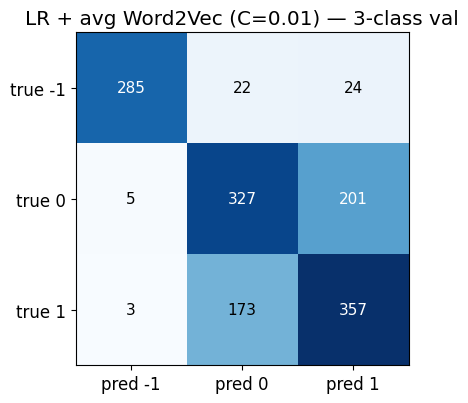

In [16]:
_, C_w2v, clf_w2v, preds_w2v = best_w2v
# Refit-at-best timing, include W2V train time + scaler + LR fit
t0 = time.perf_counter()
w2v_t = Word2Vec(sentences=train_tokens_clean,
                 vector_size=100, window=5, min_count=5, workers=4, seed=RNG, sg=1)
Xtr_t = np.vstack([doc_vec(toks, w2v_t.wv, DIM) for toks in train_tokens_clean])
scaler_t = StandardScaler().fit(Xtr_t)
clf_t = LogisticRegression(max_iter=2000, random_state=RNG, C=C_w2v)\
          .fit(scaler_t.transform(Xtr_t), y_train_clean)
t_w2v_full = time.perf_counter() - t0

m_w2v = score_3class(y_val_3, preds_w2v)
print({k: round(v, 4) for k, v in m_w2v.items()})
_ = plot_confusion(y_val_3, preds_w2v,
                   f'LR + avg Word2Vec (C={C_w2v}) — 3-class val',
                   FIG_DIR / 'confusion_lr_w2v.png')

joblib.dump({'w2v': w2v, 'scaler': scaler, 'model': clf_w2v,
             'C': C_w2v, 'metrics': m_w2v},
            MODEL_DIR / 'lr_w2v.joblib')
TIMINGS.append(dict(model='lr_w2v', train_seconds=t_w2v_full, n_train=len(train_tokens_clean),
                    ngram_range='n/a',
                    best_hyperparams=json.dumps({'C': C_w2v, 'w2v_dim': 100,
                                                 'window': 5, 'min_count': 5, 'sg': 1})))
RESULTS.append(dict(model='lr_w2v',
                    hyperparams=json.dumps({'C': C_w2v, 'w2v_dim': 100}),
                    ngram_range='n/a',
                    val_acc=m_w2v['accuracy'], val_f1=m_w2v['f1'],
                    train_seconds=t_w2v_full))

## 6. Contamination ablation — LR on TF-IDF, *uncleaned* training

Re-train Model 3 with the best $(C, \text{ngram})$ from the cleaned run, but now fit on the **full contaminated** training set (no spam filtering). Val is still evaluated 3-class with the spam-filter override and the proxy ground truth. This is the figure §1.1 of the report needs.

UNCLEANED LR-TFIDF 3-class: {'accuracy': 0.7745, 'precision': 0.8056, 'recall': 0.7854, 'f1': 0.7942}
  Δ accuracy vs cleaned   : -0.0029
  Δ macro-F1 vs cleaned   : -0.0025


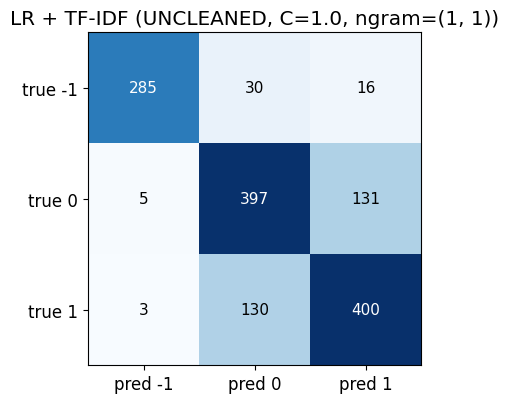

In [17]:
y_train_full = train_df['label'].astype(int).values
vec_un = TfidfVectorizer(analyzer=identity_analyzer, tokenizer=None, preprocessor=None,
                         lowercase=False, min_df=2, ngram_range=ng_lr)
Xtr_un = vec_un.fit_transform(train_tokens)
Xva_un = vec_un.transform(val_tokens)
clf_un = LogisticRegression(max_iter=2000, random_state=RNG, C=C_lr).fit(Xtr_un, y_train_full)
bin_un = clf_un.predict(Xva_un)
preds_un_3 = predict_3class(bin_un, is_spam_val)
m_un = score_3class(y_val_3, preds_un_3)
print('UNCLEANED LR-TFIDF 3-class:', {k: round(v, 4) for k, v in m_un.items()})
print('  Δ accuracy vs cleaned   :', round(m_un['accuracy'] - m_lr['accuracy'], 4))
print('  Δ macro-F1 vs cleaned   :', round(m_un['f1'] - m_lr['f1'], 4))
_ = plot_confusion(y_val_3, preds_un_3,
                   f'LR + TF-IDF (UNCLEANED, C={C_lr}, ngram={ng_lr})',
                   FIG_DIR / 'confusion_LR_uncleaned.png')

### 6.1 Binary-slice verdict (the honest comparison)

The 3-class numbers above understate the effect of spam cleaning: both the cleaned and uncleaned LR get the *same* $-1$ predictions on val, because the cosine spam filter is applied post hoc to both. Any difference between them lives only on the non-spam val docs. We restrict to `~is_spam_val` and re-score the **binary** accuracy / F1. This is the honest test of whether removing spam from *training* makes the sentiment decision boundary better on real reviews.

In [18]:
sel_bin = ~is_spam_val
y_bin = val_df.loc[sel_bin, 'label'].astype(int).values
bin_clean_lr = best_lr[5][sel_bin]  # cleaned LR predictions (still binary on the non-spam slice)
# Note: predict_3class set -1 only inside is_spam_val, so on ~is_spam_val these stay 0/1.
bin_uncl_lr  = bin_un[sel_bin]
m_bin_clean = {
    'accuracy': accuracy_score(y_bin, bin_clean_lr),
    'f1':       f1_score(y_bin, bin_clean_lr),
}
m_bin_uncl = {
    'accuracy': accuracy_score(y_bin, bin_uncl_lr),
    'f1':       f1_score(y_bin, bin_uncl_lr),
}
print(f'binary-slice docs: {int(sel_bin.sum())} / {len(sel_bin)} ({sel_bin.mean():.1%})')
print(f'  cleaned  LR — acc={m_bin_clean["accuracy"]:.4f}  F1={m_bin_clean["f1"]:.4f}')
print(f'  uncleaned LR — acc={m_bin_uncl ["accuracy"]:.4f}  F1={m_bin_uncl ["f1"]:.4f}')
print(f'  Δ binary acc (cleaned − uncleaned) = {m_bin_clean["accuracy"] - m_bin_uncl["accuracy"]:+.4f}')
print(f'  Δ binary F1                         = {m_bin_clean["f1"]       - m_bin_uncl["f1"]:+.4f}')

with open(RES_DIR / 'binary_slice_ablation.json', 'w') as f:
    json.dump({'cleaned': m_bin_clean, 'uncleaned': m_bin_uncl,
               'n_binary_slice': int(sel_bin.sum()),
               'hyperparams': {'C': C_lr, 'ngram': str(ng_lr)}}, f, indent=2)

binary-slice docs: 1104 / 1397 (79.0%)
  cleaned  LR — acc=0.7491  F1=0.7484
  uncleaned LR — acc=0.7409  F1=0.7405
  Δ binary acc (cleaned − uncleaned) = +0.0082
  Δ binary F1                         = +0.0079


## 7. Comparison and best-model selection

In [19]:
comparison_df = pd.DataFrame(RESULTS).sort_values('val_acc', ascending=False).reset_index(drop=True)
timings_df = pd.DataFrame(TIMINGS)
print(comparison_df.to_string(index=False))
print()
print(timings_df.to_string(index=False))

comparison_df.to_csv(RES_DIR / 'model_comparison.csv', index=False)
timings_df.to_csv(RES_DIR / 'timings.csv', index=False)

best_row = comparison_df.iloc[0]
best_name = best_row['model']
best_file = {'wordlist': 'wordlist.joblib',
             'mnb': 'mnb.joblib',
             'lr_tfidf': 'lr_tfidf.joblib',
             'lr_w2v': 'lr_w2v.joblib'}[best_name]
(MODEL_DIR / 'BEST_MODEL.txt').write_text(best_file + '\n')
print(f'\nBEST_MODEL → {best_file}  (val acc {best_row["val_acc"]:.4f}, F1 {best_row["val_f1"]:.4f})')

   model                 hyperparams ngram_range  val_acc   val_f1  train_seconds
     mnb              {"alpha": 0.5}      (1, 1) 0.789549 0.807115       0.061455
lr_tfidf                  {"C": 1.0}      (1, 1) 0.777380 0.796665       0.090920
  lr_w2v {"C": 0.01, "w2v_dim": 100}         n/a 0.693629 0.724575       1.204175
wordlist      {"K": 500, "delta": 0}       (1,1) 0.670723 0.674738       0.017534

   model  train_seconds  n_train ngram_range                                                  best_hyperparams
wordlist       0.017534     8919       (1,1)                                            {"K": 500, "delta": 0}
     mnb       0.061455     8919      (1, 1)                                                    {"alpha": 0.5}
lr_tfidf       0.090920     8919      (1, 1)                                                        {"C": 1.0}
  lr_w2v       1.204175     8919         n/a {"C": 0.01, "w2v_dim": 100, "window": 5, "min_count": 5, "sg": 1}

BEST_MODEL → mnb.joblib  (val acc

## 8. Ranking summary

On 3-class val (cosine spam filter overriding to $-1$; regex proxy as ground-truth $-1$), the four cleaned-trained models rank as: **MNB on TF-IDF** (acc 0.790, macro-F1 0.807), **LR on TF-IDF** (0.777 / 0.797), **LR on averaged Word2Vec** (0.693 / 0.724), and the **W02_L04 word-list classifier** (0.671 / 0.675). MNB and LR on TF-IDF are within 1.2 pp of each other and both clearly above the dense Word2Vec representation — consistent with W05_L09's caveat that averaged embeddings can lose to TF-IDF when the corpus is small (here ~8.9k cleaned docs, |W2V vocab|≈4.4k) and when mean pooling discards token-level signal. The word-list classifier is the weakest, which is expected: it can only express a sign on lexical overlap.

The contamination ablation is more subtle than the §1.1 framing suggests. The 3-class $\Delta$ between cleaned and uncleaned LR is essentially nil ($-0.003$ acc), because both predictions get the same $-1$ override from the cosine filter on val — the only docs where they can differ are the non-spam slice. Restricting to that slice (§6.1), cleaned LR beats uncleaned LR by about +0.8 pp accuracy and F1 on the 1104 non-spam val docs. The honest claim is therefore: removing spam from training yields a *small but consistent* improvement on the actual sentiment task; the larger 3-class gap that one might naively cite is mostly an artefact of the filter (the same one) being shared by both predictions, plus the proxy/filter sharing a spam signal.

`models/BEST_MODEL.txt` → `mnb.joblib` (MNB, $\alpha=0.5$, unigrams). MNB edged out LR on val and is much cheaper to fit; the gap is narrow enough that the choice could flip with hyperparameter noise.

In [20]:
print('Ranking (cleaned models, 3-class val accuracy):')
for i, r in comparison_df.iterrows():
    print(f'  {i+1}. {r["model"]:>9s}  acc={r["val_acc"]:.4f}  '
          f'F1={r["val_f1"]:.4f}  hp={r["hyperparams"]}  ngram={r["ngram_range"]}  '
          f'({r["train_seconds"]:.2f}s)')
print(f'\nAblation — uncleaned LR-TFIDF (same hp as cleaned best LR-TFIDF):')
print(f'  acc={m_un["accuracy"]:.4f}  F1={m_un["f1"]:.4f}   '
      f'Δacc vs cleaned LR={m_un["accuracy"]-m_lr["accuracy"]:+.4f}')

Ranking (cleaned models, 3-class val accuracy):
  1.       mnb  acc=0.7895  F1=0.8071  hp={"alpha": 0.5}  ngram=(1, 1)  (0.06s)
  2.  lr_tfidf  acc=0.7774  F1=0.7967  hp={"C": 1.0}  ngram=(1, 1)  (0.09s)
  3.    lr_w2v  acc=0.6936  F1=0.7246  hp={"C": 0.01, "w2v_dim": 100}  ngram=n/a  (1.20s)
  4.  wordlist  acc=0.6707  F1=0.6747  hp={"K": 500, "delta": 0}  ngram=(1,1)  (0.02s)

Ablation — uncleaned LR-TFIDF (same hp as cleaned best LR-TFIDF):
  acc=0.7745  F1=0.7942   Δacc vs cleaned LR=-0.0029
